![ATARRI logos](img/logos.png)

# 1.4 Common operations with MONARCH dust forecast outputs

#### Objective 

The objective of this notebook is to provide programming techniques to carry out common operations with MONARCH dust forecast outputs, including: statistical calculations, summary tables and time series plots.

## Introduction

Now that we understand how to work with MONARCH outputs, we can take a closer look at our dust event. For example, it is useful to calculate statistics to understand how dust has changed through time and space, how each property of dust has changed, etc.

We will start by importing our working libraries and our previous notebook, as we will use our working dust concentration dataset.

In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import os
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [2]:
root_dir = Path('/home/tvintimi/data/providentia/exp_to_interp/a00c_cirrus/regional/3hourly')
conc_path = os.path.join(root_dir, "sconc_dust/sconc_dust_2025030612.nc")
conc_ds = xr.open_dataset(conc_path)
conc_ds

<xarray.Dataset> Size: 2GB
Dimensions:     (time: 29, lev: 14, lat: 825, lon: 1650)
Coordinates:
  * time        (time) datetime64[ns] 232B 2025-03-06T12:00:00 ... 2025-03-10
  * lev         (lev) float64 112B 0.0 250.0 500.0 750.0 ... 8e+03 1e+04 1.2e+04
  * lat         (lat) float64 7kB -10.95 -10.85 -10.75 ... 71.25 71.35 71.45
  * lon         (lon) float64 13kB -62.95 -62.85 -62.75 ... 101.8 101.9 102.0
Data variables:
    sconc_dust  (time, lev, lat, lon) float32 2GB ...
Attributes:
    Domain:                     Regional
    Conventions:                CF-1.7
    comment:                    Generated on cirrus
    history_of_appended_files:  Thu Mar  6 18:03:59 2025: Appended file od550...
    NCO:                        netCDF Operators version 4.8.1 (Homepage = ht...
    history:                    Fri Mar  7 11:34:15 2025: ncap2 -O -v -s wher...

## Example 1: Statistical calculations

Because dust concentration is a 4D file, we need to subset our data before we start calculating it. We first extract `sconc_dust` and then `chunk` our dataset. The latter is a way of breaking our dataset into smaller and more manageable data blocks, so that they may be processed more efficiently without directly loading its entirety into our memory at once, which is particularly useful for larger datasets such as `sconc_dust`. We will chunk with `"time": 1` because our future calculations will happen over the `time`dimension, and with this input we will process one time step at a time.

In [3]:
data = conc_ds['sconc_dust']
data = data.chunk({"time": 1})

Now, we will select an altitude level and geographic coordinates. When subsetting the data, we can use `method="nearest"` in `xarray` to ensure that, if our input values do not exactly match with values found in the dataset, then the closest matching values are selected.

In [4]:
lev = 1000.0
lat = 35.1
lon = 33.2

In [5]:
selected_point = data.sel(lev=lev, lat=lat, lon=lon, method="nearest")
selected_point

<xarray.DataArray 'sconc_dust' (time: 29)> Size: 116B
dask.array<getitem, shape=(29,), dtype=float32, chunksize=(1,), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 232B 2025-03-06T12:00:00 ... 2025-03-10
    lat      float64 8B 35.15
    lon      float64 8B 33.25
    lev      float64 8B 1e+03
Attributes:
    grid_mapping:  crs
    units:         kgm-3

Now, we can obtain a variety of statistics from our selected point. For example, let's try calculating a mean of dust concentration values across all time steps covered in our dataset.

In [6]:
mean = selected_point.mean(dim="time").compute().item()
mean

2.0706705683437576e-08

These values are currently displayed in kg/m³, but as they are very small, converting to µg/m³ will look better for future data displays:

In [7]:
mean = mean * 1e9 * 2
mean

41.41341136687515

Let us calculate the median now. We cannot use the same structure as we did for the mean, because by default `Dask` cannot compute this over chunked dimensions and will output a `NotImplementedError`. However, since our `selected_point` is already a 1D array, we can manually calculate the median as follows:

In [8]:
median = np.median(selected_point.values)
median = median * 1e9 * 2
median

np.float32(27.04689)

Aside from the dust concentration mean and median across time, we can also calculate the maximum and minimum values.

In [9]:
max_value = selected_point.max(dim="time").compute().item()
max_value = max_value * 1e9 * 2
max_value

108.10096995328422

In [10]:
min_value = selected_point.min(dim="time").compute().item()
min_value = min_value * 1e9 * 2
min_value

3.578520250913995e-12

## Example 2: Summary tables

We have calculated several statistics separately, but it would be better if we could visualise them all at once. Using `pandas`, we can create a data frame table and populate it with our calculated variables:

In [11]:
stats = {
    "Mean (µg/m³)": mean,
    "Median (µg/m³)": median,
    "Max (µg/m³)": max_value,
    "Min (µg/m³)": min_value,
}

# Create a pandas DataFrame
df_stats = pd.DataFrame(stats, index=["Value"]).T

# Print the table
with pd.option_context('display.float_format', '{:.3f}'.format):
    print("\n--- Statistical Summary ---")
    print(df_stats)


--- Statistical Summary ---
                 Value
Mean (µg/m³)    41.413
Median (µg/m³)  27.047
Max (µg/m³)    108.101
Min (µg/m³)      0.000


This table covers statistics across the entire vertical section. If we wanted to go more in depth and look at specific vertical levels, we can apply similar logic.

First, we will create a list with the altitude levels that we want to analyse. Because dust particles are found at lower altitudes, we can look at `500`, `1000`, `2000` and `4000`. We will also create an empty dictionary to store our future statistics.

In [12]:
levels = [500, 1000, 2000, 4000]
stats_dict = {}

Next, we will loop over our `levels` and calculate each statistic as done previously. For each level, we will create a new column in our dictionary.

In [ ]:
for level in levels:
    # Select the nearest point at this level
    subset = sconc_ds.sel(lev=level, lat=lat, lon=lon, method="nearest")
    
    # Compute statistics
    mean = subset.mean(dim="time").item()
    mean = mean * 1e9

    median = subset.median(dim="time").item()
    median = median * 1e9

    max_value = subset.max(dim="time").item()
    max_value = max_value * 1e9

    min_value = subset.min(dim="time").item()
    min_value = min_value * 1e9

    # Store results in dictionary with level as column name
    stats_dict[str(level)] = {
        "Mean (µg/m³)": mean,
        "Median (µg/m³)": median,
        "Max (µg/m³)": max_value,
        "Min (µg/m³)": min_value,
    }

Once this is done, we can convert the dictionary to a data frame, and use some styling options to represent the summary table as follows:

In [14]:
df_stats = pd.DataFrame(stats_dict)

styled_df = df_stats.style.format("{:.3f}").set_table_styles(
    [{'selector': 'th', 'props': [('border', '1px solid black')]},  # Borders for header
     {'selector': 'td', 'props': [('border', '1px solid black')]},  # Borders for cells
     {'selector': 'table', 'props': [('border-collapse', 'collapse')]}]  # Collapsing borders
)

styled_df

,500,1000,2000,4000
Mean (µg/m³),56.072,41.413,40.605,34.056
Median (µg/m³),41.505,27.047,41.552,36.386
Max (µg/m³),171.261,108.101,86.644,60.407
Min (µg/m³),0.000,0.000,0.000,0.000


## Example 3: Time series

A statistical table is a great way of understanding the forecasts, but what if we wanted to plot our data?

We can make a quick time series of dust concentration at our selected data point. To start, we will subset our `time` data and convert `concdu` into µg/m³.

In [15]:
time = selected_point.time
concdu_values = selected_point * 1e9 * 2

Then, using `matplotlib`, we can create our linear time-series plot. After setting our figure size, we need to establish our plot parameters:

- `time`: x-axis values.
- `concdu_values`: y-axis values.
- `marker='o'`: creates a circle marker at each data point.
- `linestyle='-'`: connects data points with a solid line.
- `color='b'`: sets the marker and line colour to blue.
- `label`: adds a label to the line, which we will set to `concdu` for this plot.

After our main plot structure, we need to customise our formatting. We will add:

- x label
- y label
- Plot title
- grid lines (we will add a `--` line style and 0.5 size)
- legend (shows the label that we set earlier)

Finally, we will do some extra formatting for our x-axis.

First, we need to retrieve the x-axis so it can be modified (`plt.gca()`). Then, we will set the label formatting with `DateFormatter` so that we display our full time from the dataset, in the format `%Y-%m-%d %H:%M:%S`. Finally, because our dates are quite long, to avoid overlaps, we can use the `plt.gcf().autofmt_xdate()
` method to automatically rotate and align them.

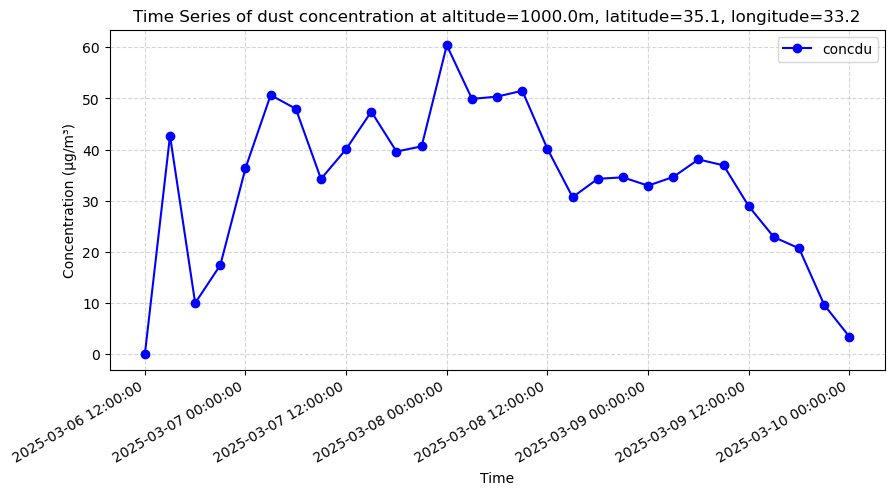

In [16]:
# Plot the time series
plt.figure(figsize=(10, 5))
plt.plot(time, concdu_values, marker='o', linestyle='-', color='b', label='concdu')

# Formatting
plt.xlabel("Time")
plt.ylabel("Concentration (µg/m³)")
plt.title(f"Time Series of dust concentration at altitude={lev}m, latitude={lat}, longitude={lon}")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()

# Format x-axis to show hours, minutes, and seconds
ax = plt.gca()  # Get current axis
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d %H:%M:%S"))  # Format as HH:MM:SS

plt.gcf().autofmt_xdate() # Auto-format date labels to prevent overlap

# Show the plot
plt.show()

## References and further reading

- `xarray` [documentation](https://docs.xarray.dev/en/stable/generated/xarray.open_dataset.html)
- `Xarray.mean` [documentation](https://docs.xarray.dev/en/latest/generated/xarray.DataArray.mean.html)
- `Xarray.median` [documentation](https://docs.xarray.dev/en/latest/generated/xarray.DataArray.median.html)
- `matplotlib` [documentation](https://matplotlib.org/stable/users/explain/quick_start.html)
- `pandas.DataFrame` [documentation](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html)
- `chunk` [documentation](https://docs.xarray.dev/en/stable/generated/xarray.Dataset.chunk.html)

<table style="width:100%;">
    <tr>
        <td style="text-align: center;"><a href="VT1-3-model_data_structure.ipynb" style="font-size: 18px;">⬅ Previous</a></td>
        <td style="text-align: center;"><a href="VT1-5-multi_model.ipynb" style="font-size: 18px;">Next ➡</a></td>
    </tr
</table>